# Deep Learning for Text Analytics

Aleksandar Malkoc, 606943

# Libraries

In [ ]:
# !pip install keras_tuner  # Uncomment if not installed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
!pip install keras_tuner
import keras_tuner

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error


In [ ]:
# Import data

#Predictor features on the train set:
train_X=pd.read_csv('train_X.csv',sep=',',header=0,index_col=0)
#Target variable on the train set:
train_y=pd.read_csv('train_y.csv',sep=',',header=0,index_col=0)
#Predictor features on the test set:
test_X=pd.read_csv('test_X.csv',sep=',',header=0,index_col=0)
#Demo predictions file:
#demo_predictions=pd.read_csv('Demo_Predictions.csv',sep=',',header=0,index_col=0)

# EDA

Distribution of target variable right skewed. Scaling neccessary.

### Scaling of the target variable

Distribution of target variable right skewed. Scaling neccessary.

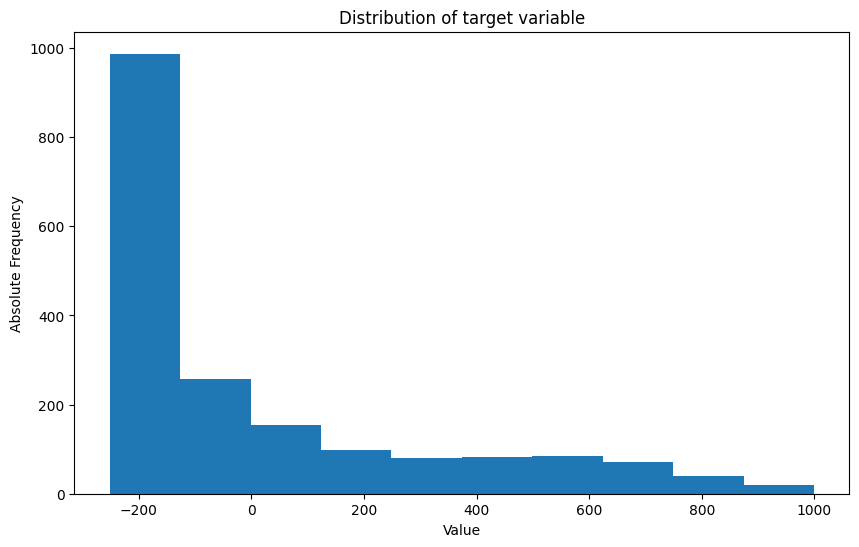

In [ ]:
#print(train_y.min()) # -251.717
#print(train_y.max()) # 999.546

#train_y.describe()


plt.figure(figsize=(10,6))
plt.hist(train_y)
plt.xlabel('Value')
plt.ylabel('Absolute Frequency')
plt.title('Distribution of target variable')
plt.show()
plt.close()

Analyzing the distribution of X

Features of different distributions: Yeo-Johnson most suitable, because can deao with different distributions as well as negative values (unlike Box-Cox).

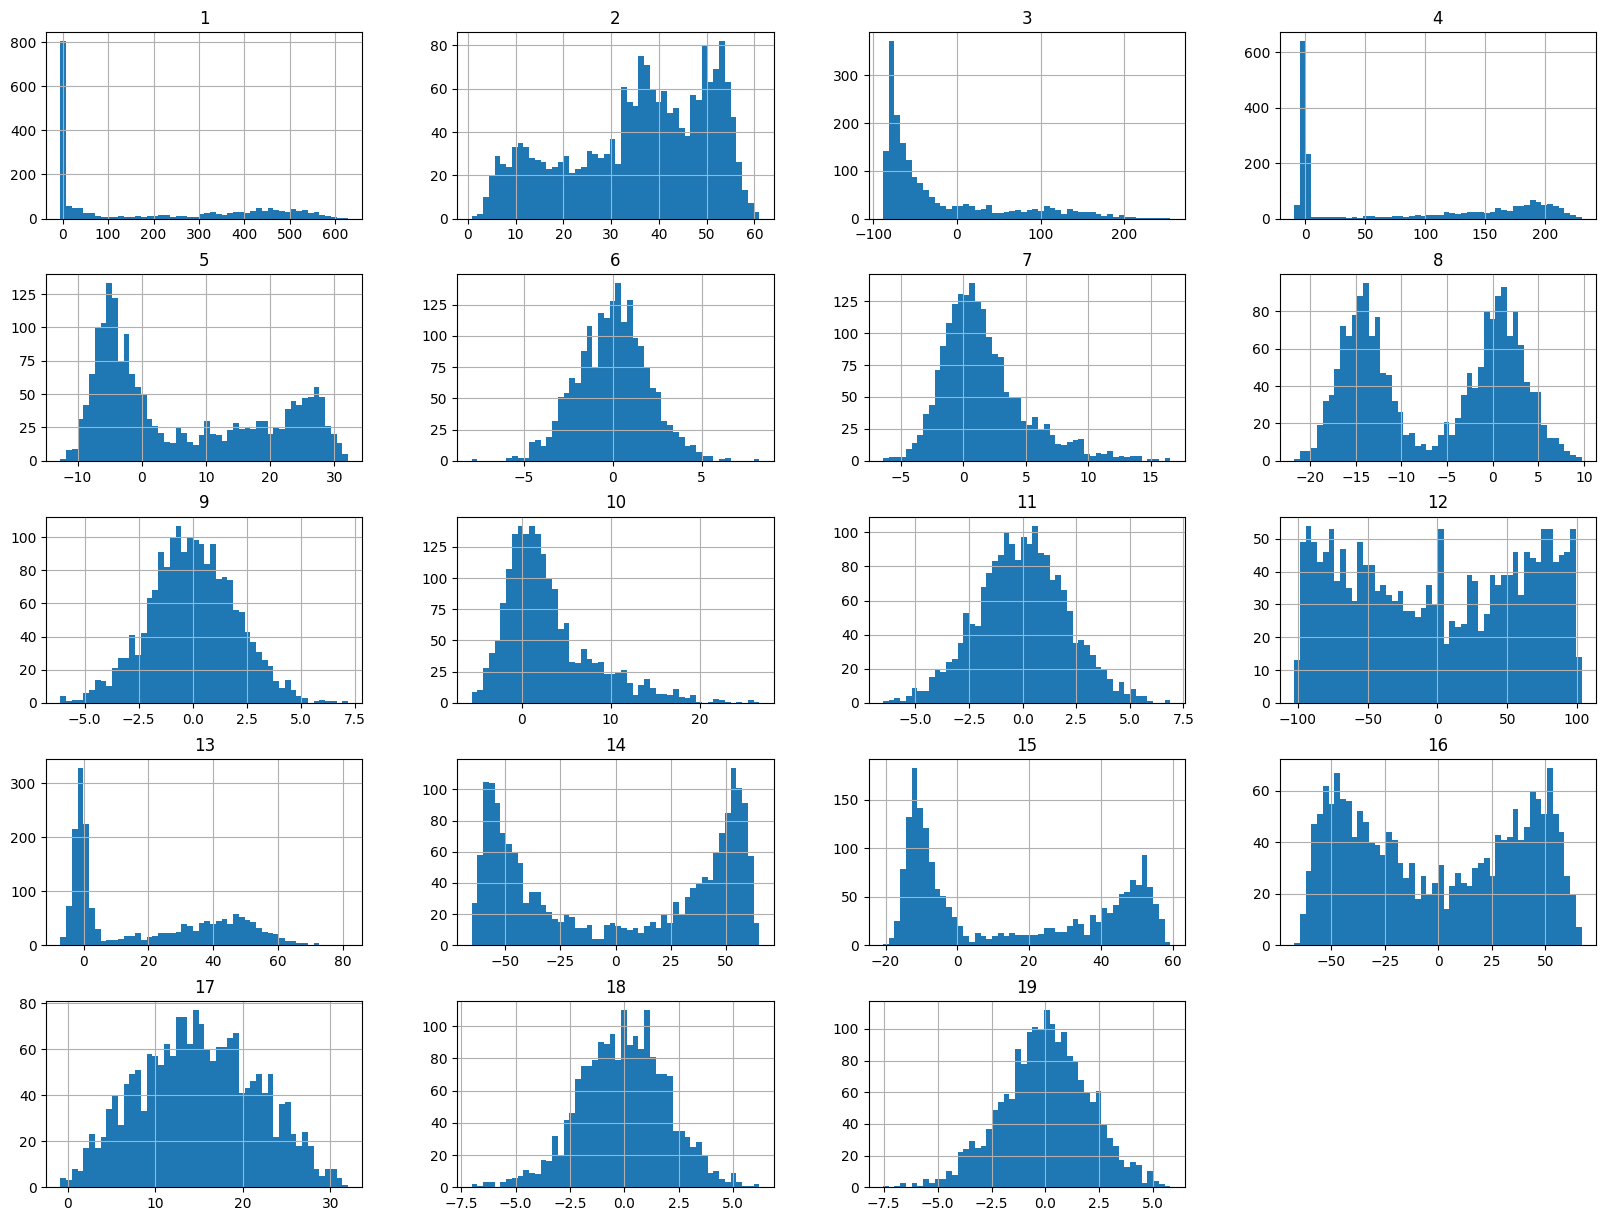

In [ ]:
# Histogram of each feature

train_X.hist(bins=50, figsize=(20,15))
plt.show()
plt.close()

# Preprocessing

Manually assiging validation data to avoid information leakage.

80/20 Split: 375/1875 rows for validation

In [ ]:
# 1875 rows -> 375 val

train_X,val_X=train_X.iloc[:1500,:],train_X.iloc[1500:,:]
train_y,val_y=train_y.iloc[:1500],train_y.iloc[1500:]


train_X.shape, val_X.shape

((1500, 19), (375, 19))

Scaling features and data using Yeo-Johnson, since there are many different distributions in the X data. Besides, there are negative values which Box-Cox could not handle.

In [ ]:
def preprocess(train_X, train_y, test_X):
    pt_X = PowerTransformer(method='yeo-johnson')
    pt_y = PowerTransformer(method='yeo-johnson')

    train_X_scaled = pt_X.fit_transform(train_X)
    test_X_scaled = pt_X.transform(test_X)

    train_y_scaled = pt_y.fit_transform(train_y)

    return train_X_scaled, train_y_scaled, test_X_scaled, pt_X, pt_y

# Baseline Models




### Linear Regression Model

In [ ]:
def train_linear(X_train, y_train, X_val, y_val, y_scaler):
    """
    Trains a linear regression model.
    Assumes inputs are scaled and returns RMSE in original target scale.
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds_inv = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    rmse_lr = mean_squared_error(y_val, preds_inv) ** 0.5
    return rmse_lr

def train_rf(X_train, y_train, X_val, y_val, y_scaler):
    """
    Trains a random forest model.
    Can handle unscaled data very well.
    """
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train.flatten())
    preds = model.predict(X_val)
    preds_inv = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    rmse_rf = mean_squared_error(y_val, preds_inv) ** 0.5
    return rmse_rf

def train_mlp(X_train, y_train, X_val, y_val, y_scaler):
    """
    Trains an MLPRegressor.
    Assumes inputs are scaled. Returns RMSE in original target scale.
    """
    model = MLPRegressor(hidden_layer_sizes=[10], max_iter=500, random_state=42)
    model.fit(X_train, y_train.flatten())
    preds = model.predict(X_val)
    preds_inv = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    rmse_mlp = mean_squared_error(y_val, preds_inv) ** 0.5
    return rmse_mlp


# Building the optimal model

In [ ]:
# Tuned Model

def keras_hp_optimization(hp: keras_tuner.HyperParameters) -> keras.Sequential:
    '''
    Perform hyperparameter tuning using keras.

    Parameters:
    -----------
    hp : keras_tuner.HyperParameters
        A set of keras tuner hyperparameters, which can be sampled during the search.

    Returns:
    --------
    model : keras.Sequential
        The keras model built with the sampled hyperparameters in the current trial.
    '''

    model = tf.keras.Sequential()
    max_hidden_layers = 5
    keep_sampling_hidden_units = True
    nr_hidden_layer = 0

    while keep_sampling_hidden_units:
        if nr_hidden_layer == 0:
            current_hidden_units = hp.Int(f'units_{nr_hidden_layer}', min_value=64, max_value=288, step=16)
        else:
            current_hidden_units = hp.Int(f'units_{nr_hidden_layer}', min_value=0, max_value=288, step=16)

        if current_hidden_units == 0 or nr_hidden_layer == max_hidden_layers - 1:
            keep_sampling_hidden_units = False

        if current_hidden_units != 0:
            current_activation = hp.Choice(f'activation_{nr_hidden_layer}', ['relu', 'tanh', 'elu', 'sigmoid'])

            if current_activation in ['relu', 'elu']:
                initializer = hp.Choice(f'init_{nr_hidden_layer}', ['he_uniform', 'he_normal'])
            else:
                initializer = hp.Choice(f'init_{nr_hidden_layer}', ['glorot_uniform', 'glorot_normal'])

            reg_type = hp.Choice(f'regularizer_{nr_hidden_layer}', ['none', 'dropout', 'l2', 'l1'])
            if reg_type in ['l1', 'l2']:
                reg_strength = hp.Float(f'reg_strength_{nr_hidden_layer}', 1e-6, 1e-2, sampling='log')
            else:
                reg_strength = 0.0

            if reg_type == 'l1':
                kernel_reg = keras.regularizers.l1(reg_strength)
            elif reg_type == 'l2':
                kernel_reg = keras.regularizers.l2(reg_strength)
            else:
                kernel_reg = None

            model.add(keras.layers.Dense(
                units=current_hidden_units,
                activation=current_activation,
                kernel_initializer=initializer,
                kernel_regularizer=kernel_reg
            ))

            if reg_type == 'dropout':
                dropout_rate = hp.Float(f'dropout_rate_{nr_hidden_layer}', 0.0, 0.4, step=0.05)
                model.add(keras.layers.Dropout(dropout_rate))

        nr_hidden_layer += 1

    batch_size = hp.Choice('batch_size', [32, 64])

    model.add(keras.layers.Dense(units=1, activation='linear'))

    current_optimizer = hp.Choice('optimizer', ['adam'])
    current_learning_rate = hp.Float('Learning_Rate', min_value=0.0010, max_value=0.0020, sampling='log')

    optimizer = (
        keras.optimizers.Adam(learning_rate=current_learning_rate)
        if current_optimizer == 'adam'
        else keras.optimizers.SGD(learning_rate=current_learning_rate)
    )

    model.compile(optimizer=optimizer, loss='mse')

    return model


In [ ]:
X_train_scaled, y_train_scaled, X_test_scaled, pt_X, pt_y = preprocess(train_X, train_y, test_X)
X_val_scaled = pt_X.transform(val_X)
y_val_scaled = pt_y.transform(val_y)

In [ ]:
tuner = keras_tuner.Hyperband(
    keras_hp_optimization,
    objective='val_loss',
    max_epochs=70,
    factor=3,
    directory='/content/',
    project_name='tf_keras_tuner_hb',
    overwrite=True
)

tuner.search(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled))
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model_hyperband = tuner.get_best_models()[0]



Trial 90 Complete [00h 00m 29s]
val_loss: 0.005558195523917675

Best val_loss So Far: 0.00219333590939641
Total elapsed time: 00h 15m 00s


In [ ]:
# rebuild best model
#best_model_hyperband = tuner.hypermodel.build(best_hp)

history_best = best_model_hyperband.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    batch_size=32,
    epochs=50
)


y_pred_hb_scaled = best_model_hyperband.predict(X_val_scaled).flatten()
y_pred_hb_original = pt_y.inverse_transform(y_pred_hb_scaled.reshape(-1, 1)).flatten()
rmse_hyperband = mean_squared_error(val_y, y_pred_hb_original)**0.5

print("RMSE (Hyperband Tuned NN):", round(rmse_hyperband, 4))

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - val_loss: 0.0059
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042 - val_loss: 0.0054
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0091
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - val_loss: 0.0053
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0034 - val_loss: 0.0049
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0042
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0076
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - val_loss: 0.0023
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_lo

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


Print parameters of top 5 models (for tuning refinement)

In [ ]:

top_hps = tuner.get_best_hyperparameters(5)
hp_dicts = [hp.values for hp in top_hps]
hp_df = pd.DataFrame(hp_dicts)

hp_df_transposed = hp_df.transpose()
hp_df_transposed.columns = [f"Model_{i+1}" for i in range(hp_df_transposed.shape[1])]
display(hp_df_transposed)

,Model_1,Model_2,Model_3,Model_4,Model_5
units_0,64,160,160,64,272
activation_0,sigmoid,tanh,elu,sigmoid,relu
init_0,he_normal,he_normal,he_uniform,he_normal,he_normal
regularizer_0,none,none,l2,none,l1
units_1,240,144,32,240,144
optimizer,adam,adam,adam,adam,adam
Learning_Rate,0.001683,0.001664,0.001452,0.001786,0.00133
dropout_rate_0,0.4,0.2,0.05,0.15,0.05
activation_1,elu,elu,elu,relu,relu
init_1,he_uniform,he_normal,he_normal,he_uniform,he_normal


Plot training versus valdation loss

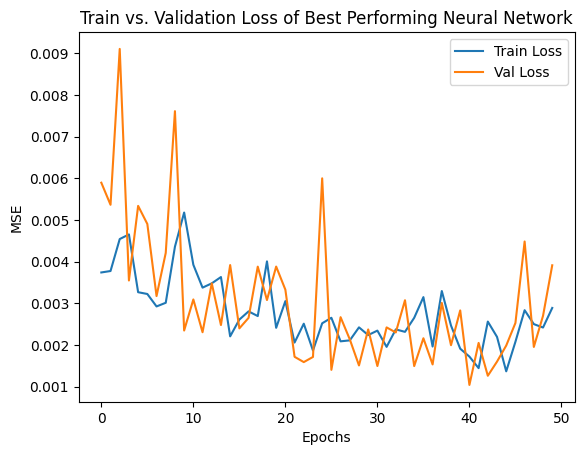

In [ ]:
def plot_loss(history_best):
    plt.plot(history_best.history['loss'], label='Train Loss')
    plt.plot(history_best.history['val_loss'], label='Val Loss')
    plt.title('Train vs. Validation Loss of Best Performing Neural Network')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

plot_loss(history_best)

Validation loss very close to training loss, implying a good generalization on new data. Both converge, so there is no indication of either under- of overfitting.

# Evaluate all results

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Untuned NN", "Tuned NN"],
    "RMSE": [
        train_linear(X_train_scaled, y_train_scaled, X_val_scaled, val_y, pt_y),
        train_rf(X_train_scaled, y_train_scaled, X_val_scaled, val_y, pt_y),
        train_mlp(X_train_scaled, y_train_scaled, X_val_scaled, val_y, pt_y),
        rmse_hyperband
    ]
})

print(results)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


               Model       RMSE
0  Linear Regression  59.355358
1      Random Forest   9.017914
2         Untuned NN  51.669660
3           Tuned NN  18.450730


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


The architecture is suitable for the task, as it was tuned stepwise, to figure out ideal ranges for each hyperparameters included. Parameters that were not selected often, were left out of the tuning. The final model is suitable, but there certainly are better architectures.

# Making the predictions

In [ ]:
def make_prediction_df(model, X_test_scaled, target_scaler, filename=None):
    """
    Generate predictions and return a properly formatted DataFrame.

    Parameters:
    - model: Trained Keras or sklearn model
    - X_test_scaled: Scaled test input
    - target_scaler: PowerTransformer used to inverse-transform predictions
    - filename: Optional CSV filename to save the predictions

    Returns:
    - DataFrame with predictions
    """
    preds_scaled = model.predict(X_test_scaled)
    preds = target_scaler.inverse_transform(preds_scaled).flatten()
    df_preds = pd.DataFrame({'Predictions': preds})
    df_preds.index.name = ''
    df_preds.reset_index(inplace=True)
    if filename:
        df_preds.to_csv(filename, index=False)
    return df_preds


In [ ]:
# write final csv for my predictions
pred_df = make_prediction_df(best_model_hyperband, X_test_scaled, pt_y, filename="task1_606943_aleksandar_malkoc.csv")

# check to see if they look logical
print(pred_df.head())


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
      Predictions
0  0  -220.671997
1  1  -211.898087
2  2  -213.786346
3  3  -245.966721
4  4  -173.264038


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
